In [133]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [134]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

In [135]:
from src.dominick import DominickDataLoader
from src.dominick.multiproduct_builder import MultiProductBuilder
from src.nn.data import ColumnEncoder, DataLoaderFactory, SplineBuilder
from src.nn.spline import CubicSplineBasis, MultiCubicSplineBasis
from src.nn.models import IntegrableDemandHead, ICDN
from src.nn.loss import ElasticityLoss
from src.multiproduct import MultiProductDataset, MultiProductContextEmbeddings
from src.nn.diagnostics import ClosureDiagnostics, SymmetryElasticityDiagnostics

# Cargar y Preparar Datos

In [136]:
loader = DominickDataLoader()
df = loader.load("elasticity_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Dataset shape: (1966147, 10)
Columnas: ['store_code', 'upc_code', 'week_id', 'liters_per_upc', 'on_promo', 'promo_B', 'promo_C', 'promo_S', 'log_price_per_liter', 'log_liters_sold']


# Factorizar colmnas Categóricas

In [137]:
encoder = ColumnEncoder()
_, store_cats = encoder.factorize(df, "store_code", sort=True)
_, week_cats  = encoder.factorize(df, "week_id",    sort=True)

n_stores = len(store_cats)
n_weeks  = len(week_cats)
print(f"Tiendas: {n_stores}  |  Semanas: {n_weeks}")

Tiendas: 89  |  Semanas: 302


# Dataset

In [138]:
# ── 1. Split temporal ─────────────────────────────────────────────
sorted_weeks   = sorted(df["week_id"].unique())
week_threshold = sorted_weeks[int(len(sorted_weeks) * 0.8)]
train_df_raw   = df[df["week_id"] < week_threshold].copy()
val_df_raw     = df[df["week_id"] >= week_threshold].copy()

# ── 2. Pipeline multi-producto ────────────────────────────────────
mp_builder = MultiProductBuilder()
mp_builder.fit(train_df_raw, n = 2)
train_wide = mp_builder.transform(train_df_raw)
val_wide   = mp_builder.transform(val_df_raw)
n = mp_builder.n

# ── 3. Encoding consistente store/week ────────────────────────────
store_map = {v: i for i, v in enumerate(store_cats)}
week_map  = {v: i for i, v in enumerate(week_cats)}
for w in [train_wide, val_wide]:
    w["store_code"] = w["store_code"].map(store_map)
    w["week_id"]    = w["week_id"].map(week_map)

# ── 4. Dataset y DataLoaders ──────────────────────────────────────
train_dataset = MultiProductDataset(train_wide, n=n)
val_dataset   = MultiProductDataset(val_wide,   n=n)

loader_factory = DataLoaderFactory(num_workers=4, pin_memory=True)
train_loader = loader_factory.create_train_loader(train_dataset, shuffle=True, drop_last=True)
val_loader   = loader_factory.create_eval_loader(val_dataset, shuffle=False)

print(f"Train: {len(train_wide):,}  |  Val: {len(val_wide):,}")
print(f"Total UPCs seleccionados: {len(mp_builder.selected_upcs)}")
print(f"Top 4: {mp_builder.selected_upcs[:4]}")

Train: 482  |  Val: 122
Total UPCs seleccionados: 2
Top 4: [1820000784, 3410010505]


# Configuración de Spline

In [139]:
builder = SplineBuilder()
n_knots = 10

spline_configs = []
for i in range(n):
    x_i = train_wide[f"log_price_{i}"].values
    config = builder.build_from_data(x_i, n_knots=n_knots, q_min=0.05, q_max=0.95)
    spline_configs.append(config)       # ← faltaba este append

for i, cfg in enumerate(spline_configs):
    print(f"Producto {i}: mean={cfg['mean']:.4f}, std={cfg['std']:.4f}, knots={cfg['knots'].shape}")

week_min = float(min(train_df_raw.week_id.min(), val_df_raw.week_id.min()))  # 91
week_max = float(max(train_df_raw.week_id.max(), val_df_raw.week_id.max()))  # 399
print(f"Week range: [{week_min:.0f}, {week_max:.0f}]")

Producto 0: mean=0.5556, std=0.0984, knots=torch.Size([10])
Producto 1: mean=0.4758, std=0.1216, knots=torch.Size([10])
Week range: [91, 399]


# Construir Modelo

In [140]:
context_builder = MultiProductContextEmbeddings(
    n=n,
    n_stores=n_stores,
    d_store=16,
    fourier_period=52.0,
    fourier_harmonics=4,
    include_trend=True,
    week_min=week_min,
    week_max=week_max,
    regressors={"rolling_mean_y"}
)

print(f"Context dimension: {context_builder.out_dim}")

Context dimension: 31


In [141]:
# 2. Price splines (una por producto)
knots = torch.stack([cfg["knots"] for cfg in spline_configs], dim=0)  # (n, K)
shift = torch.tensor([cfg["mean"] for cfg in spline_configs])
scale = torch.tensor([cfg["std"]  for cfg in spline_configs])

price_splines = MultiCubicSplineBasis(knots=knots, shift=shift, scale=scale)

In [142]:
head = IntegrableDemandHead(
    context_dim=context_builder.out_dim,
    K_splines=n_knots,        # variable que definiste al construir las splines
    n=n,                        # número de productos
    hidden=(32, 16, 8),
    act="gelu",
    dropout=0.1,
    use_cross=False,
)

In [143]:
# 4. Modelo completo
model = ICDN(
    context_builder=context_builder,
    price_splines=price_splines,  # ModuleList de n CubicSplineBasis
    head=head,
    n=n,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"\nModelo creado en device: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo creado en device: cuda
Parámetros totales: 3,328


# Configurar el modelo

In [144]:
# Loss function
loss_fn = ElasticityLoss(
    huber_delta=1.0,
    lambda_smooth=1e-3,   
    lambda_pos=0.1,      
    reduction="none"
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-5
)

# Learning rate scheduler (opcional)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15,
    min_lr=1e-5
)

# AMP scaler para mixed precision training
scaler = torch.amp.GradScaler('cuda') if device == "cuda" else None


print("Configuración de entrenamiento lista")

Configuración de entrenamiento lista


# Entrenamiento

In [145]:
n_epochs   = 150
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_mae": [], "lr": []}

print("Iniciando entrenamiento...")
print("=" * 80)

for epoch in range(n_epochs):

    # ── TRAIN ─────────────────────────────────────────────────────────────────
    model.train()
    train_losses = []

    for batch in train_loader:
        batch  = {k: v.to(device) for k, v in batch.items()}
        y_true = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n)], dim=1
        )                                                        # (B, n)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=(scaler is not None)):
            y_hat, eps_hat, aux = model(batch, return_parts=True) # (B,n), (B,n)
            obs_mask = torch.stack(
                [batch[f"obs_mask_{i}"] for i in range(n)], dim=1
            ).to(device)  # (B, n)

            loss, logs = loss_fn(
                y_hat, y_true, eps_hat,
                obs_mask,
                aux["w"],
                aux["ddBx"],
                aux["u"],
                aux["Bx"],
                aux["IBx"],
                aux["pairs"],
            )

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        train_losses.append(logs["loss"].item())

    # ── VALIDATION ────────────────────────────────────────────────────────────
    model.eval()
    val_losses, val_maes = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            y_true = torch.stack(
                [batch[f"log_liters_{i}"] for i in range(n)], dim=1
            )                                                    # (B, n)

            y_hat, eps_hat, aux = model(batch, return_parts=True)
            obs_mask = torch.stack(
                [batch[f"obs_mask_{i}"] for i in range(n)], dim=1
            ).to(device)
            _, logs = loss_fn(
                y_hat, y_true, eps_hat,
                obs_mask,
                aux["w"],
                aux["ddBx"],
                aux["u"],
                aux["Bx"],
                aux["IBx"],
                aux["pairs"],
            )
            val_losses.append(logs["loss"].item())
            masked_mae = ((y_hat - y_true).abs() * obs_mask).sum() / obs_mask.sum().clamp(min=1.0)
            val_maes.append(masked_mae.item())

    train_loss = float(np.mean(train_losses))
    val_loss   = float(np.mean(val_losses))
    val_mae    = float(np.mean(val_maes))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    scheduler.step(val_loss)

    # ── LOG ───────────────────────────────────────────────────────────────────
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}  |  MAE: {val_mae:.4f}")
    print(f"  Elasticity - Mean: {logs['eps_mean']:.4f}  |  Median: {logs['eps_p50']:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": best_val_loss,
        }, "../models/best_model.pt")
        print(f"  ✓ Mejor modelo guardado (val_loss: {best_val_loss:.4f})")

    print("-" * 80)

print(f"\nEntrenamiento completado  |  Mejor val_loss: {best_val_loss:.4f}")

Iniciando entrenamiento...
Epoch 1/150
  Train - Loss: 7.5481
  Val   - Loss: 2.3710  |  MAE: 1.7877
  Elasticity - Mean: 2.3365  |  Median: -0.1922
  LR: 0.010000
  ✓ Mejor modelo guardado (val_loss: 2.3710)
--------------------------------------------------------------------------------
Epoch 2/150
  Train - Loss: 3.0740
  Val   - Loss: 1.9490  |  MAE: 1.7952
  Elasticity - Mean: 1.1339  |  Median: -0.1210
  LR: 0.010000
  ✓ Mejor modelo guardado (val_loss: 1.9490)
--------------------------------------------------------------------------------
Epoch 3/150
  Train - Loss: 2.6390
  Val   - Loss: 1.9053  |  MAE: 1.6492
  Elasticity - Mean: 1.6851  |  Median: -0.0498
  LR: 0.010000
  ✓ Mejor modelo guardado (val_loss: 1.9053)
--------------------------------------------------------------------------------
Epoch 4/150
  Train - Loss: 2.3488
  Val   - Loss: 1.7625  |  MAE: 1.5153
  Elasticity - Mean: 1.8877  |  Median: 0.0576
  LR: 0.010000
  ✓ Mejor modelo guardado (val_loss: 1.7625)
---

# Visualización de Resultados

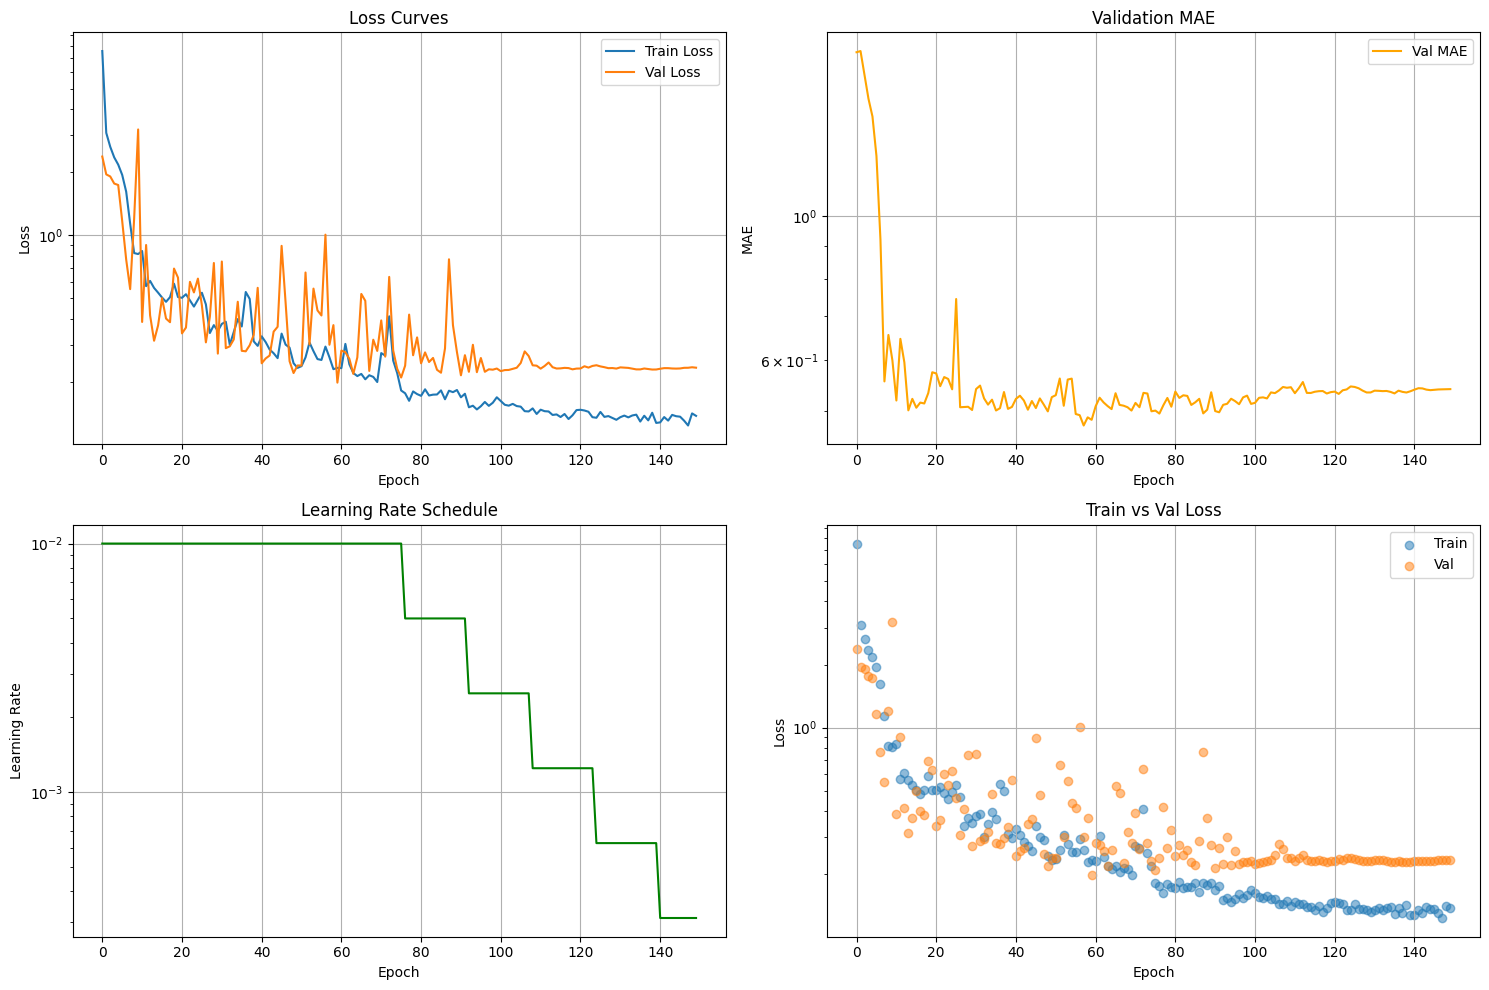

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True)

# MAE
axes[0, 1].plot(history['val_mae'], label='Val MAE', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Validation MAE')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Learning rate
axes[1, 0].plot(history['lr'], color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True)

# Loss comparison
axes[1, 1].scatter(range(len(history['train_loss'])), 
                   history['train_loss'], alpha=0.5, label='Train')
axes[1, 1].scatter(range(len(history['val_loss'])), 
                   history['val_loss'], alpha=0.5, label='Val')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Train vs Val Loss')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150)
plt.show()

# Evaluación Final

In [147]:
# Cargar mejor modelo
checkpoint = torch.load('../models/best_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en validación
model.eval()
all_preds        = []
all_targets      = []
all_masks        = []
all_elasticities = []
all_stores = [] 

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        y_hat, eps_hat, _ = model.run(batch, return_parts=True)

        y_true = torch.stack(
            [batch[f"log_liters_{i}"] for i in range(n)], dim=1
        )
        obs_mask = torch.stack(
            [batch[f"obs_mask_{i}"] for i in range(n)], dim=1
        )

        all_preds.append(y_hat.cpu())
        all_targets.append(y_true.cpu())
        all_masks.append(obs_mask.cpu())
        all_elasticities.append(eps_hat.cpu())
        all_stores.append(batch["store_code"].cpu())

preds        = torch.cat(all_preds).numpy()        # (N, n)
targets      = torch.cat(all_targets).numpy()      # (N, n)
masks        = torch.cat(all_masks).numpy().astype(bool)  # (N, n)
elasticities = torch.cat(all_elasticities).numpy()

# --- métricas SOLO sobre productos observados ---
preds_obs   = preds[masks]
targets_obs = targets[masks]

mae = np.mean(np.abs(preds_obs - targets_obs))
mse = np.mean((preds_obs - targets_obs) ** 2)
r2  = 1 - (np.sum((targets_obs - preds_obs)**2) /
           np.sum((targets_obs - targets_obs.mean())**2))

print(f"Observaciones evaluadas: {masks.sum():,} / {masks.size:,}  "
      f"({100*masks.mean():.1f}% observadas)")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  R²:   {r2:.4f}")

Observaciones evaluadas: 235 / 244  (96.3% observadas)
  MAE:  0.4848
  MSE:  0.4045
  R²:   0.0233


# Diagnostics

In [148]:
# ── Cross-derivatives symmetry (Slutsky) ─────────────────────────────────
sym_diag = SymmetryElasticityDiagnostics()
sym_penalties = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = sym_diag.run(model=model, batch=batch)
        sym_penalties.append(out.penalty.item())

print(f"Slutsky symmetry residual (val):  {np.mean(sym_penalties):.2e}")

# ── 2. Schwarz / C² sanity check (∂_k∂_j y_i - ∂_j∂_k y_i) ─────────────
cl_diag = ClosureDiagnostics()
cl_penalties = []

with torch.no_grad():
    batch_sample = next(iter(val_loader))
    batch_sample = {k: v.to(device) for k, v in batch_sample.items()}
    _, _, aux = model.run(batch_sample, return_parts=True)

# u: (B, n_cross, K, K),  Bx: (B, n, K),  dBx: (B, n, K)
u   = aux['u']      # (B, n_cross, K, K)
Bx  = aux['Bx']     # (B, n, K)
dBx = aux['dBx']    # (B, n, K)

pairs = model.head.param_head._pairs   # (2, n_cross)
B, n_cross, K, _ = u.shape
n = model.n

# E_cross[b, i, j] = ∂y_i/∂x_j = Σ_{k,l} u_{ij,kl} * B_k(x_i) * B'_l(x_j)
E_cross = torch.zeros(B, n, n, device=device)
for p in range(n_cross):
    i, j = pairs[0, p].item(), pairs[1, p].item()
    # i < j: ∂y_i/∂x_j
    E_cross[:, i, j] = torch.einsum('bk,bkl,bl->b', Bx[:, i], u[:, p], dBx[:, j])
    # j > i: ∂y_j/∂x_i = same (Slutsky)
    E_cross[:, j, i] = E_cross[:, i, j]

idx = torch.triu_indices(n, n, offset=1)
cross_vals = E_cross[:, idx[0], idx[1]].cpu().numpy().flatten()

print(f"\nElasticidades cruzadas ∂y_i/∂x_j (en precios del batch):")
print(f"  Media:   {cross_vals.mean():.4f}")
print(f"  Std:     {cross_vals.std():.4f}")
print(f"  Min:     {cross_vals.min():.4f}")
print(f"  Max:     {cross_vals.max():.4f}")

Slutsky symmetry residual (val):  0.00e+00

Elasticidades cruzadas ∂y_i/∂x_j (en precios del batch):
  Media:   0.0000
  Std:     0.0000
  Min:     0.0000
  Max:     0.0000


# Analisis Predicciones

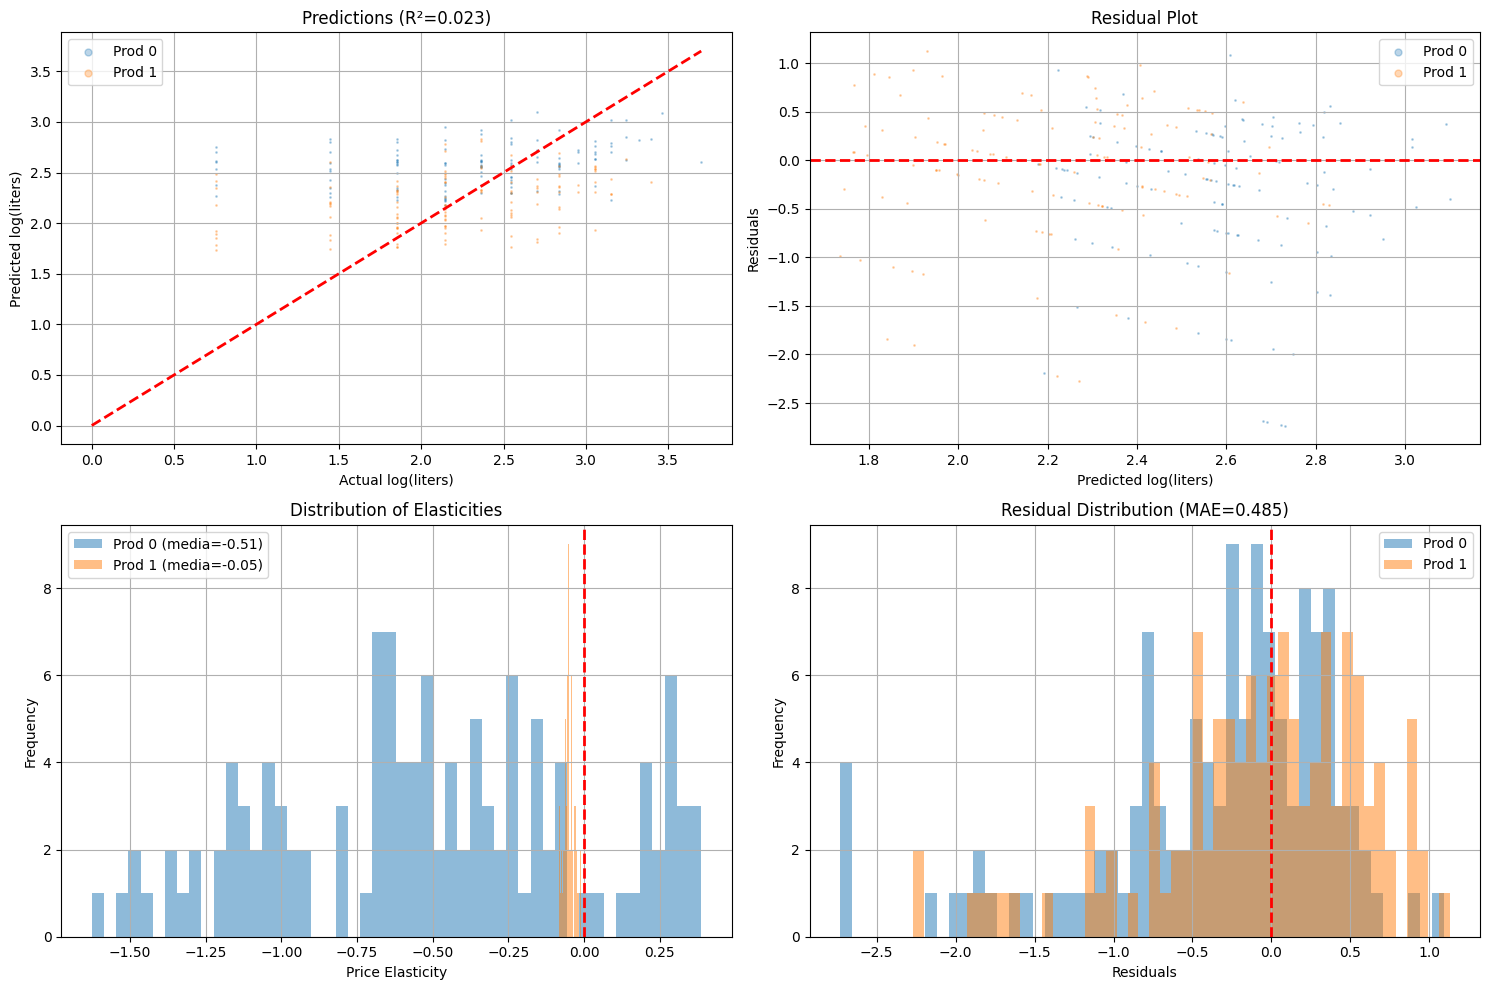


✓ Pipeline completado exitosamente


In [149]:
colors = [cm.tab10(i) for i in range(n)]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Predicted vs Actual — por producto
for i in range(n):
    mask_i = masks[:, i]
    axes[0, 0].scatter(
        targets[mask_i, i], preds[mask_i, i],
        alpha=0.3, s=1, color=colors[i], label=f'Prod {i}'
    )
axes[0, 0].plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()], 'r--', lw=2
)
axes[0, 0].set_xlabel('Actual log(liters)')
axes[0, 0].set_ylabel('Predicted log(liters)')
axes[0, 0].set_title(f'Predictions (R²={r2:.3f})')
axes[0, 0].legend(markerscale=5)
axes[0, 0].grid(True)

# Residual Plot — por producto
residuals = targets - preds   # (N, n)
for i in range(n):
    axes[0, 1].scatter(
        preds[:, i], residuals[:, i],
        alpha=0.3, s=1, color=colors[i], label=f'Prod {i}'
    )
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted log(liters)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].legend(markerscale=5)
axes[0, 1].grid(True)

# Distribution of Elasticities — por producto
for i in range(n):
    axes[1, 0].hist(
        elasticities[:, i], bins=50, alpha=0.5,
        color=colors[i],
        label=f'Prod {i} (media={elasticities[:, i].mean():.2f})'
    )
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Price Elasticity')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Elasticities')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Residual Distribution — por producto
for i in range(n):
    axes[1, 1].hist(
        residuals[:, i], bins=50, alpha=0.5,
        color=colors[i], label=f'Prod {i}'
    )
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Residual Distribution (MAE={mae:.3f})')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../results/evaluation_plots.png', dpi=150)
plt.show()

print("\n✓ Pipeline completado exitosamente")

In [150]:
# ── Métricas por (store, producto) ───────────────────────────────────────────
import pandas as pd

upc_labels = [str(upc) for upc in mp_builder.selected_upcs]

# --- 1. Reconstruir store_code por fila del batch ----------------------------
# (necesitas haberlo guardado en el loop de eval; si no lo tienes, añade
#  all_stores.append(batch["store_code"].cpu()) dentro del loop)
stores = torch.cat(all_stores).numpy()          # (N,)  — índice ya mapeado
store_inv = {v: k for k, v in store_map.items()}  # índice → código original

# --- 2. Construir tabla larga ------------------------------------------------
rows = []
for i in range(n):
    mask_i = masks[:, i]
    if mask_i.sum() == 0:
        continue

    y_true_i  = targets[mask_i, i]
    y_pred_i  = preds[mask_i, i]
    eps_i     = elasticities[mask_i, i]
    stores_i  = stores[mask_i]

    for s in np.unique(stores_i):
        s_mask = stores_i == s
        y_t = y_true_i[s_mask]
        y_p = y_pred_i[s_mask]
        e   = eps_i[s_mask]

        ss_res = np.sum((y_t - y_p) ** 2)
        ss_tot = np.sum((y_t - y_t.mean()) ** 2)

        rows.append({
            "store_code": store_inv.get(int(s), int(s)),
            "upc":        upc_labels[i],
            "upc_idx":    i,
            "n_obs":      int(s_mask.sum()),
            "mae":        round(float(np.mean(np.abs(y_p - y_t))), 4),
            "r2":         round(float(1 - ss_res / ss_tot), 4) if ss_tot > 0 else float("nan"),
            "eps_p05":    round(float(np.percentile(e,  5)), 3),
            "eps_p50":    round(float(np.percentile(e, 50)), 3),
            "eps_p95":    round(float(np.percentile(e, 95)), 3),
            "pct_neg":    round(100.0 * (e < 0).mean(), 1),
        })

df_store_upc = pd.DataFrame(rows)

# --- 3. Vista resumen por UPC (mediana de métricas sobre tiendas) -------------
summary = (df_store_upc
    .groupby("upc")
    .agg(
        n_stores    = ("store_code", "nunique"),
        n_obs_total = ("n_obs",  "sum"),
        mae_median  = ("mae",    "median"),
        r2_median   = ("r2",     "median"),
        eps_p50_median = ("eps_p50", "median"),
        pct_neg_median = ("pct_neg", "median"),
    )
    .round(4)
)
print("=== Resumen por UPC (mediana sobre tiendas) ===")
print(summary.to_string())

# --- 4. Vista detallada (store × UPC) ----------------------------------------
print("\n=== Detalle (store × UPC) ===")
print(df_store_upc
      .sort_values(["upc_idx", "store_code"])
      .to_string(index=False))

=== Resumen por UPC (mediana sobre tiendas) ===
            n_stores  n_obs_total  mae_median  r2_median  eps_p50_median  pct_neg_median
upc                                                                                     
1820000784         2          117       0.501    -0.1012          -0.653           81.25
3410010505         2          118       0.469    -0.0256          -0.050          100.00

=== Detalle (store × UPC) ===
 store_code        upc  upc_idx  n_obs    mae      r2  eps_p05  eps_p50  eps_p95  pct_neg
        101 1820000784        0     60 0.4664 -0.0637   -0.710   -0.345    0.317     80.0
        128 1820000784        0     57 0.5356 -0.1387   -1.491   -0.961    0.283     82.5
        101 3410010505        1     57 0.4487 -0.0057   -0.061   -0.045   -0.013    100.0
        128 3410010505        1     61 0.4892 -0.0454   -0.080   -0.055   -0.031    100.0


In [151]:
for i in range(n):
    mask_i = masks[:, i]
    if mask_i.sum() == 0: continue
    y_true_i = targets[mask_i, i]
    y_pred_i = preds[mask_i, i]
    print(f"UPC {upc_labels[i]}: "
          f"σ(y_true)={y_true_i.std():.3f}  "
          f"σ(y_pred)={y_pred_i.std():.3f}  "
          f"bias={( y_pred_i.mean() - y_true_i.mean() ):.3f}")

UPC 1820000784: σ(y_true)=0.649  σ(y_pred)=0.211  bias=0.255
UPC 3410010505: σ(y_true)=0.632  σ(y_pred)=0.268  bias=0.013


In [152]:
# Diagnóstico: compara medias train vs val por producto
for i in range(n):
    mask_train = train_wide[f"obs_mask_{i}"] == 1
    mask_val   = val_wide[f"obs_mask_{i}"]   == 1
    m_train = train_wide.loc[mask_train, f"log_liters_{i}"].mean()
    m_val   = val_wide.loc[mask_val,   f"log_liters_{i}"].mean()
    print(f"UPC {mp_builder.selected_upcs[i]}: "
          f"mean_train={m_train:.3f}  mean_val={m_val:.3f}  "
          f"shift={m_val - m_train:.3f}")

UPC 1820000784: mean_train=3.124  mean_val=2.329  shift=-0.796
UPC 3410010505: mean_train=2.974  mean_val=2.210  shift=-0.765


In [153]:
# Descomposición de varianza de y_pred
# ¿Cuánto varía por tienda vs por semana?
for i in range(n):
    mask_i = masks[:, i]
    if mask_i.sum() == 0: continue

    y_p = preds[mask_i, i]
    s   = stores[mask_i]

    var_total   = y_p.var()
    var_between = np.array([y_p[s == si].mean() for si in np.unique(s)]).var()

    print(f"UPC {upc_labels[i]}: "
          f"σ_pred={y_p.std():.3f}  "
          f"var_between_stores={var_between:.4f}  "
          f"var_total={var_total:.4f}  "
          f"% explicado por tienda={100*var_between/var_total if var_total>0 else 0:.1f}%")

UPC 1820000784: σ_pred=0.211  var_between_stores=0.0222  var_total=0.0445  % explicado por tienda=49.9%
UPC 3410010505: σ_pred=0.268  var_between_stores=0.0483  var_total=0.0719  % explicado por tienda=67.1%


In [154]:
for i in range(n):
    mask_i = masks[:, i]
    if mask_i.sum() == 0: continue

    yt = targets[mask_i, i]
    yp = preds[mask_i, i]

    # R² estándar (penaliza bias de nivel)
    ss_res = np.sum((yt - yp)**2)
    ss_tot = np.sum((yt - yt.mean())**2)
    r2_std = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    # R² centrado (solo mide si capta la dinámica, ignora el offset)
    yt_c = yt - yt.mean()
    yp_c = yp - yp.mean()
    ss_res_c = np.sum((yt_c - yp_c)**2)
    ss_tot_c = np.sum(yt_c**2)
    r2_cen = 1 - ss_res_c / ss_tot_c if ss_tot_c > 0 else float("nan")

    print(f"UPC {upc_labels[i]}: R²_std={r2_std:.3f}  R²_centered={r2_cen:.3f}  "
          f"bias={yp.mean()-yt.mean():.3f}")

UPC 1820000784: R²_std=-0.083  R²_centered=0.072  bias=0.255
UPC 3410010505: R²_std=0.117  R²_centered=0.117  bias=0.013
